# Introduction

In this project, you will build a neural network of your own design to evaluate the CIFAR-10 dataset.
Our target accuracy is 70%, but any accuracy over 50% is a great start.
Some of the benchmark results on CIFAR-10 include:

78.9% Accuracy | [Deep Belief Networks; Krizhevsky, 2010](https://www.cs.toronto.edu/~kriz/conv-cifar10-aug2010.pdf)

90.6% Accuracy | [Maxout Networks; Goodfellow et al., 2013](https://arxiv.org/pdf/1302.4389.pdf)

96.0% Accuracy | [Wide Residual Networks; Zagoruyko et al., 2016](https://arxiv.org/pdf/1605.07146.pdf)

99.0% Accuracy | [GPipe; Huang et al., 2018](https://arxiv.org/pdf/1811.06965.pdf)

98.5% Accuracy | [Rethinking Recurrent Neural Networks and other Improvements for ImageClassification; Nguyen et al., 2020](https://arxiv.org/pdf/2007.15161.pdf)

Research with this dataset is ongoing. Notably, many of these networks are quite large and quite expensive to train. 

## Imports

In [1]:
## This cell contains the essential imports you will need – DO NOT CHANGE THE CONTENTS! ##
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

## Load the Dataset

Specify your transforms as a list first.
The transforms module is already loaded as `transforms`.

CIFAR-10 is fortunately included in the torchvision module.
Then, you can create your dataset using the `CIFAR10` object from `torchvision.datasets` ([the documentation is available here](https://pytorch.org/docs/stable/torchvision/datasets.html#cifar)).
Make sure to specify `download=True`! 

Once your dataset is created, you'll also need to define a `DataLoader` from the `torch.utils.data` module for both the train and the test set.

In [2]:
# Define transforms
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

batch_size = 128

# Create training set and define training dataloader
trainset = torchvision.datasets.CIFAR10(root='./CIFAR10', train=True,
                                        download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

# Create test set and define test dataloader
testset = torchvision.datasets.CIFAR10(root='./CIFAR10', train=False,
                                       download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

# The 10 classes in the dataset
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

## Explore the Dataset
Using matplotlib, numpy, and torch, explore the dimensions of your data.

You can view images using the `show5` function defined below – it takes a data loader as an argument.
Remember that normalized images will look really weird to you! You may want to try changing your transforms to view images.
Typically using no transforms other than `toTensor()` works well for viewing – but not as well for training your network.
If `show5` doesn't work, go back and check your code for creating your data loaders and your training/test sets.

In [3]:
def show5(img_loader):
    dataiter = iter(img_loader)
    
    batch = next(dataiter)
    labels = batch[1][0:5]
    images = batch[0][0:5]
    for i in range(5):
        print(classes[labels[i]])
    
        image = images[i].numpy()
        plt.imshow(image.T)
        plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.88235295].


dog


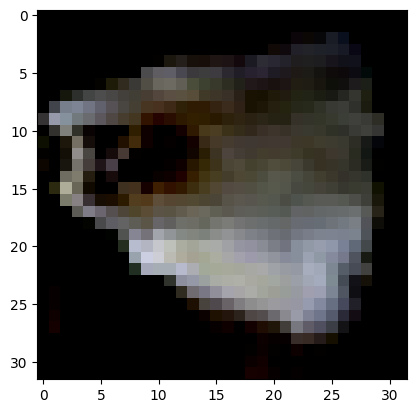

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.90588236].


frog


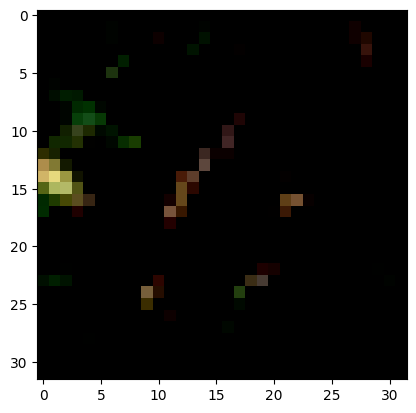

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


truck


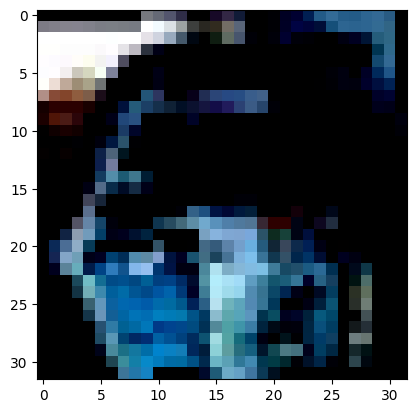

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.75686276].


dog


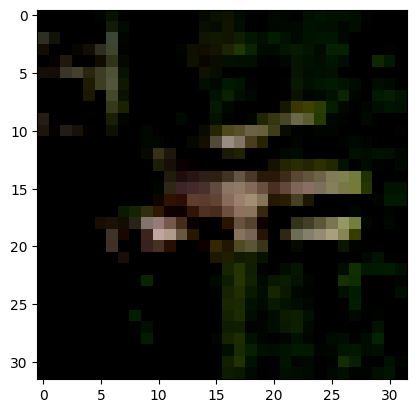

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.99215686].


cat


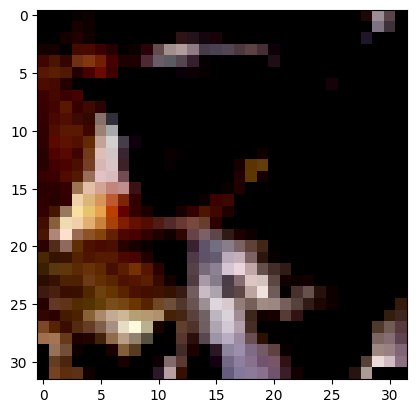

cat


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8980392..1.0].


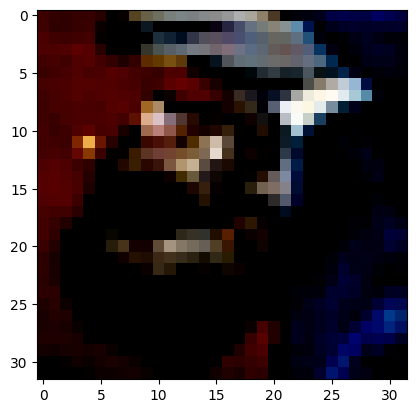

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.9372549].


ship


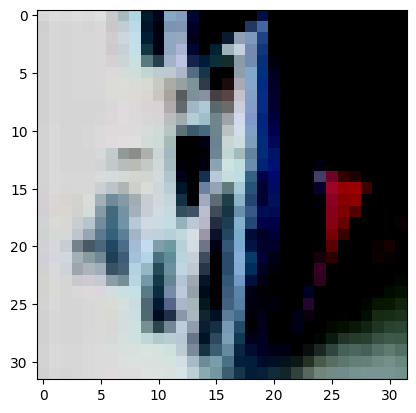

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9764706..0.9764706].


ship


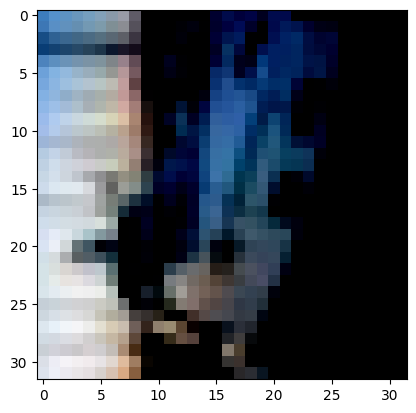

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7411765..0.8352941].


plane


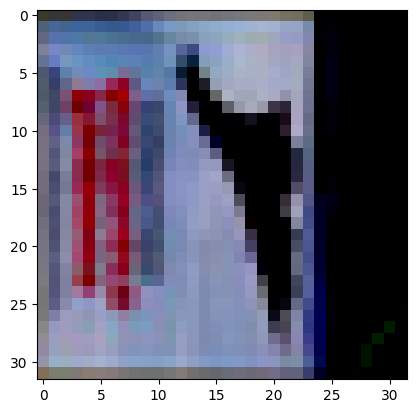

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9529412..0.7254902].


frog


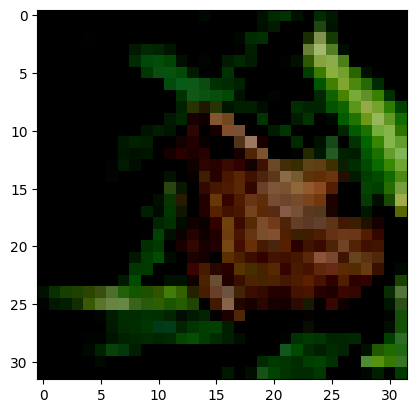

In [4]:
# Explore data
show5(trainloader)
show5(testloader)

## Build your Neural Network
Using the layers in `torch.nn` (which has been imported as `nn`) and the `torch.nn.functional` module (imported as `F`), construct a neural network based on the parameters of the dataset. 
Feel free to construct a model of any architecture – feedforward, convolutional, or even something more advanced!

In [5]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()

        # CIFAR-10 images are 32x32x3 = 3072 pixels
        self.flatten = nn.Flatten()
        
        # Fully connected layers with decreasing sizes
        self.fc1 = nn.Linear(3072, 1024)  # Input: 32*32*3 = 3072
        self.dropout1 = nn.Dropout(0.5)
        
        self.fc2 = nn.Linear(1024, 512)
        self.dropout2 = nn.Dropout(0.5)
        
        self.fc3 = nn.Linear(512, 256)
        self.dropout3 = nn.Dropout(0.3)
        
        self.fc4 = nn.Linear(256, 128)
        self.dropout4 = nn.Dropout(0.3)
        
        self.fc5 = nn.Linear(128, 64)
        self.dropout5 = nn.Dropout(0.2)
        
        self.fc6 = nn.Linear(64, 10)  # Output: 10 classes
        
    def forward(self, x):
        # Flatten the image to 1D vector
        x = self.flatten(x)  # [batch_size, 3072]
        
        # Pass through fully connected layers
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        
        x = F.relu(self.fc3(x))
        x = self.dropout3(x)
        
        x = F.relu(self.fc4(x))
        x = self.dropout4(x)
        
        x = F.relu(self.fc5(x))
        x = self.dropout5(x)
        
        x = self.fc6(x)

        x = F.softmax(x, dim=1)
        
        return x

Specify a loss function and an optimizer, and instantiate the model.

If you use a less common loss function, please note why you chose that loss function in a comment.

In [6]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instantiate model
model = Model().to(device)

# Loss function and optimizer
criterion = nn.NLLLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## Running your Neural Network
Use whatever method you like to train your neural network, and ensure you record the average loss at each epoch. 
Don't forget to use `torch.device()` and the `.to()` method for both your model and your data if you are using GPU!

If you want to print your loss during each epoch, you can use the `enumerate` function and print the loss after a set number of batches. 250 batches works well for most people!

In [7]:
train_losses, test_losses = [], []
epochs = 100

for epoch in range(epochs):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = model(inputs)
        log_probs = torch.log(outputs + 1e-8)
        loss = criterion(log_probs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
    else:
        tot_test_loss = 0
        test_correct = 0  # Number of correct predictions on the test set
        
        # Turn off gradients for validation, saves memory and computations
        with torch.no_grad():
            model.eval()  # Set the model to evaluation mode
            for images, labels in testloader:
                images, labels = images.to(device), labels.to(device)
                output = model(images)
                log_probs = torch.log(output + 1e-8)
                loss = criterion(log_probs, labels)
                tot_test_loss += loss.item()

                _, top_class = torch.max(log_probs, 1)
                equals = top_class == labels.view(*top_class.shape)
                test_correct += equals.sum().item()

        model.train()

        train_loss = running_loss / len(trainloader.dataset)
        test_loss = tot_test_loss / len(testloader.dataset)
        running_loss = 0.0

        train_losses.append(train_loss)
        test_losses.append(test_loss)

        print("Epoch: {}/{}.. ".format(epoch + 1, epochs),
            "Training Loss: {:.3f}.. ".format(train_loss),
            "Test Loss: {:.3f}.. ".format(test_loss),
            "Test Accuracy: {:.3f}".format(test_correct / len(testloader.dataset)))

print('Finished Training')

Epoch: 1/100..  Training Loss: 0.015..  Test Loss: 0.014..  Test Accuracy: 0.371
Epoch: 2/100..  Training Loss: 0.014..  Test Loss: 0.013..  Test Accuracy: 0.424
Epoch: 3/100..  Training Loss: 0.013..  Test Loss: 0.013..  Test Accuracy: 0.444
Epoch: 4/100..  Training Loss: 0.013..  Test Loss: 0.012..  Test Accuracy: 0.459
Epoch: 5/100..  Training Loss: 0.013..  Test Loss: 0.012..  Test Accuracy: 0.473
Epoch: 6/100..  Training Loss: 0.013..  Test Loss: 0.012..  Test Accuracy: 0.473
Epoch: 7/100..  Training Loss: 0.013..  Test Loss: 0.012..  Test Accuracy: 0.480
Epoch: 8/100..  Training Loss: 0.012..  Test Loss: 0.012..  Test Accuracy: 0.495
Epoch: 9/100..  Training Loss: 0.012..  Test Loss: 0.012..  Test Accuracy: 0.485
Epoch: 10/100..  Training Loss: 0.012..  Test Loss: 0.011..  Test Accuracy: 0.494
Epoch: 11/100..  Training Loss: 0.012..  Test Loss: 0.011..  Test Accuracy: 0.494
Epoch: 12/100..  Training Loss: 0.012..  Test Loss: 0.011..  Test Accuracy: 0.500
Epoch: 13/100..  Training

Plot the training loss (and validation loss/accuracy, if recorded).

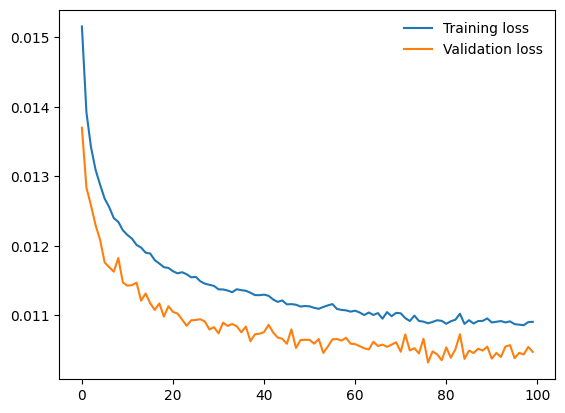

In [8]:
plt.plot(train_losses, label='Training loss')
plt.plot(test_losses, label='Validation loss')
plt.legend(frameon=False)

## Testing your model
Using the previously created `DataLoader` for the test set, compute the percentage of correct predictions using the highest probability prediction. 

If your accuracy is over 70%, great work! 
This is a hard task to exceed 70% on.

If your accuracy is under 45%, you'll need to make improvements.
Go back and check your model architecture, loss function, and optimizer to make sure they're appropriate for an image classification task.

In [9]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images_for_inference, labels_for_inference = images.to(device), labels.to(device)
        # calculate outputs by running images through the network
        outputs = model(images_for_inference)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        total += labels_for_inference.size(0)
        correct += (predicted == labels_for_inference).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

Accuracy of the network on the 10000 test images: 48 %


## Saving your model
Using `torch.save`, save your model for future loading.

In [10]:
PATH = './cifar_net.pth'
torch.save(model.state_dict(), PATH)

## Make a Recommendation

Based on your evaluation, what is your recommendation on whether to build or buy? Explain your reasoning below.

The model I used in this notebook only achieves an accuracy of 48%, which is much lower than the accuracy of Detectocorp’s model that can be bought. But so far in the course we have built deep neural networks using only fully connected layers. A model using convolutional layers could be implemented that could most likely achieve the required accuracy of 70%.

Having only fully connected layers to work with, I would recommend buying Detecorp's model.